<a href="https://colab.research.google.com/github/xtianu/CV_Tirana_2026/blob/main/M2_Image%20Segmentation/Exercise%202.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Module 2: IMAGE SEGMENTATION

Christian Mata, PhD

# Exercise 2

**Before starting:**

- Create a GitHub repository to upload the solution of this exercise.
- Share this GitHub link to your professor.

**Objectives**

Generate a single Python notebook implementing and answering the following questions:

**Task 1:** Load an image and apply a thresholding method. Analyze and discuss the segmentation results.

**Task 2:** Load an image and apply an unsupervised segmentation method (e.g., K-Means). Evaluate and comment on the outcome.

**Task 3:** Load an image and apply a supervised segmentation method (e.g., with annotated labels or using a classifier). Discuss the effectiveness and limitations.

**Task 4:** Explain the main differences between supervised and unsupervised segmentation approaches. Discuss their advantages and disadvantages, and illustrate your explanation with an example.


Imports I will use through the whole notebook.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, color, feature, future
from skimage.filters import threshold_otsu, threshold_local
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from functools import partial

np.random.seed(42)

## Task 1 - Thresholding

For this task I used the page image from skimage, which is a grayscale photo of a piece of paper with printed text on it. The idea is to separate the dark text from the bright paper. I tried two methods: Otsu (one threshold for the whole image) and a local adaptive threshold.

Otsu threshold = 157


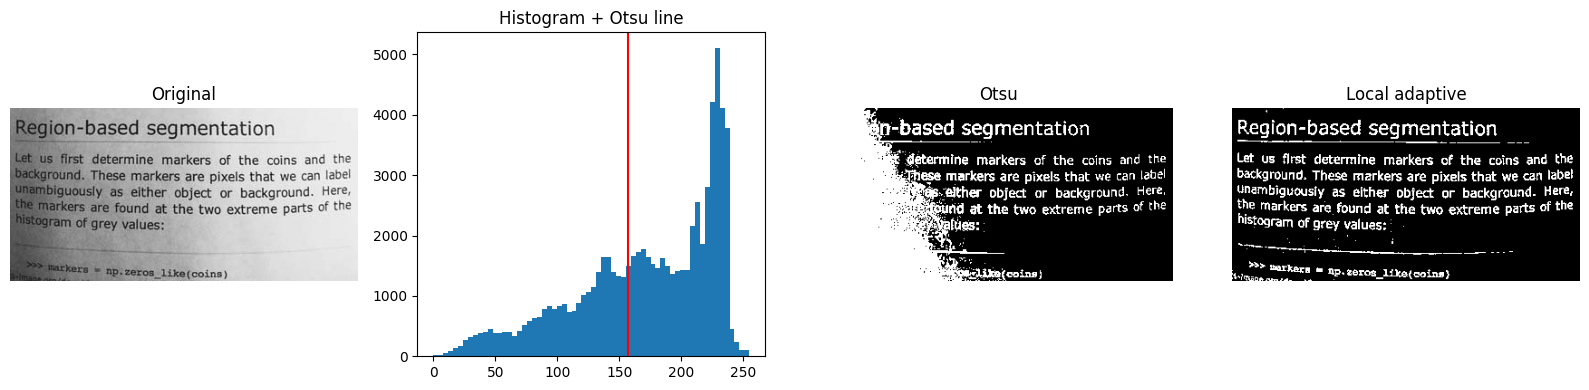

In [2]:
img_page = data.page()

# global otsu threshold
t = threshold_otsu(img_page)
binary_otsu = img_page < t  # text is darker than paper

# local adaptive threshold
local_t = threshold_local(img_page, block_size=35, offset=10)
binary_local = img_page < local_t

print('Otsu threshold =', t)

fig, ax = plt.subplots(1, 4, figsize=(16, 4))
ax[0].imshow(img_page, cmap='gray')
ax[0].set_title('Original')
ax[1].hist(img_page.ravel(), bins=64)
ax[1].axvline(t, color='r')
ax[1].set_title('Histogram + Otsu line')
ax[2].imshow(binary_otsu, cmap='gray')
ax[2].set_title('Otsu')
ax[3].imshow(binary_local, cmap='gray')
ax[3].set_title('Local adaptive')
for a in [ax[0], ax[2], ax[3]]:
    a.axis('off')
plt.tight_layout()
plt.show()

The page image is a typical case where thresholding can struggle: the lighting is not the same everywhere, the left part of the paper is brighter than the right. Because Otsu picks a single value for the whole image, some letters on the darker side of the page get merged with the paper, and some shadowed areas appear as if they were ink.

The local adaptive threshold gives a much cleaner result on the text, because each pixel is compared to its own neighborhood. The price is that it also detects small intensity changes that are not really text, so the mask has some noise.

In general, thresholding only looks at intensity and ignores shape or spatial information. It works well when the image has a clear bimodal histogram, but it is sensitive to non-uniform illumination and to objects that have similar intensities to the background.

## Task 2 - Unsupervised segmentation (K-Means)

For unsupervised segmentation I used K-Means on the chelsea image (a photo of a cat). Each pixel is just an (R, G, B) vector, and K-Means groups them into K clusters. I tried K = 2, 4 and 6 to see how the result changes.

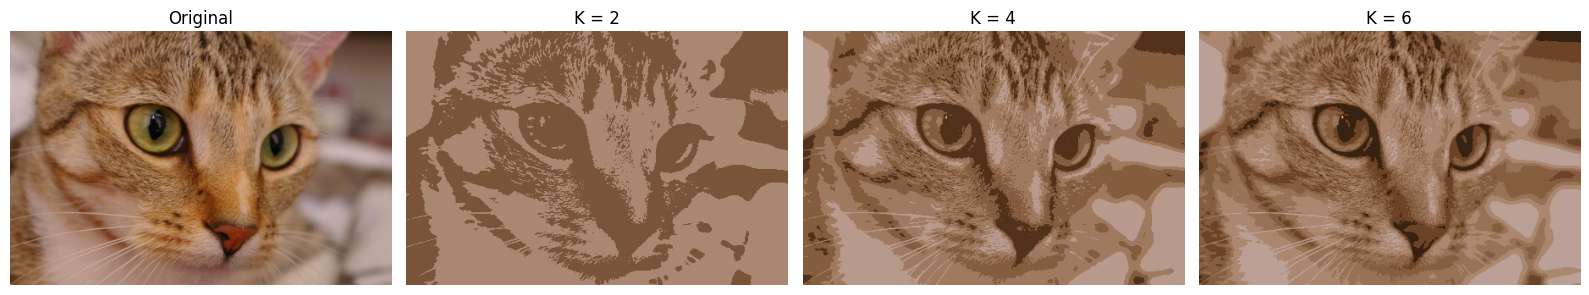

In [3]:
img = data.chelsea()
h, w, c = img.shape
pixels = img.reshape(-1, 3).astype(np.float32) / 255.0

Ks = [2, 4, 6]
fig, ax = plt.subplots(1, len(Ks) + 1, figsize=(16, 4))
ax[0].imshow(img)
ax[0].set_title('Original')
ax[0].axis('off')

for i, K in enumerate(Ks, start=1):
    km = KMeans(n_clusters=K, n_init=4, random_state=42).fit(pixels)
    seg = km.cluster_centers_[km.labels_].reshape(h, w, 3)
    ax[i].imshow(seg)
    ax[i].set_title('K = ' + str(K))
    ax[i].axis('off')

plt.tight_layout()
plt.show()

With K=2 the image is basically split into a dark part (the cat fur in the shadow) and a brighter part (background + lighter fur). With K=4 we start to see the dark fur, the light fur, the green-ish background and the lighter highlights as separate regions. With K=6 the segmentation gets more detailed but also a bit messy, because pixels with similar colors from different objects end up in the same cluster.

The advantage is that K-Means does not need any labels and is very fast. The problem is that the clusters do not have any meaning: the algorithm only knows about colors, not about objects. It also has no idea of pixel position so the regions can be scattered, and it is not obvious which K to pick.

## Task 3 - Supervised segmentation (Random Forest)

For the supervised part I used the coffee image (a top view of a cup of coffee on a table) and a Random Forest classifier. The idea is the same as in tools like ilastik or trainable Weka: I draw a few strokes saying which pixels are "cup" and which are "table", compute features for every pixel (gaussian, edges, hessian at different scales), train a Random Forest on the labeled pixels, and then predict the class of every pixel.

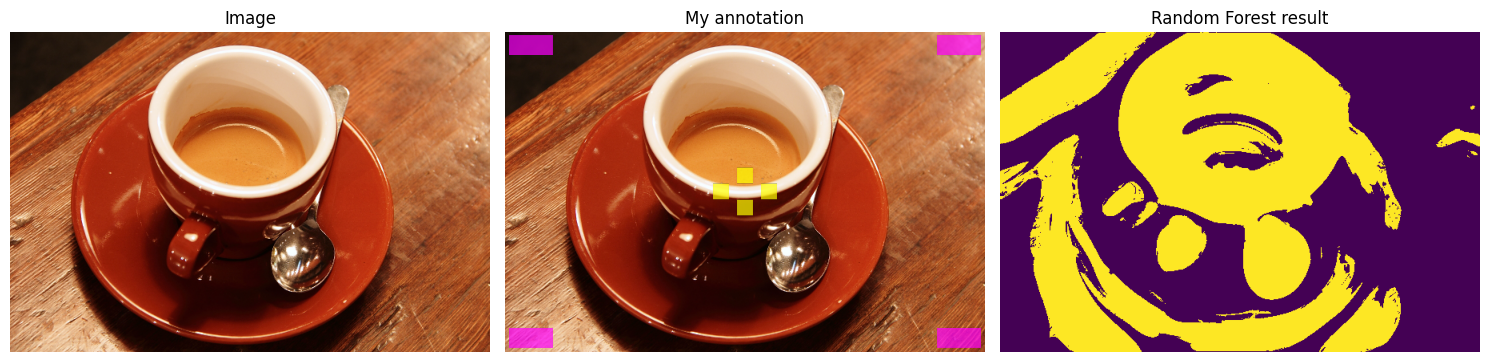

In [4]:
img_rgb = data.coffee()
img_gray = color.rgb2gray(img_rgb)
h, w = img_gray.shape

# 0 = unlabeled, 1 = table (background), 2 = cup + coffee
labels = np.zeros((h, w), dtype=np.uint8)
# table strokes (corners of the image)
labels[5:30, 5:60] = 1
labels[5:30, w-60:w-5] = 1
labels[h-30:h-5, 5:60] = 1
labels[h-30:h-5, w-60:w-5] = 1
# cup/coffee strokes (central part of the image)
labels[h//2-30:h//2-10, w//2-10:w//2+10] = 2
labels[h//2+10:h//2+30, w//2-10:w//2+10] = 2
labels[h//2-10:h//2+10, w//2-40:w//2-20] = 2
labels[h//2-10:h//2+10, w//2+20:w//2+40] = 2

# build the feature stack
features_func = partial(
    feature.multiscale_basic_features,
    intensity=True, edges=True, texture=True,
    sigma_min=1, sigma_max=16,
    channel_axis=None,
)
features = features_func(img_gray)

clf = RandomForestClassifier(n_estimators=50, n_jobs=-1, max_depth=10, random_state=42)
clf = future.fit_segmenter(labels, features, clf)
result = future.predict_segmenter(features, clf)

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(img_rgb)
ax[0].set_title('Image')
ax[1].imshow(img_rgb)
ax[1].imshow(np.ma.masked_where(labels == 0, labels), cmap='spring', alpha=0.7)
ax[1].set_title('My annotation')
ax[2].imshow(result, cmap='viridis')
ax[2].set_title('Random Forest result')
for a in ax:
    a.axis('off')
plt.tight_layout()
plt.show()

Even with only a few strokes, the Random Forest manages to separate the cup from the table quite well. It performs better than what a simple threshold would do on this image, because the cup and the table have overlapping intensities in some regions, while the classifier also uses texture and gradient features at different scales.

The main limitations I see are:
- the result depends a lot on the strokes I draw; if they are not representative the classifier makes wrong predictions,
- a model trained on this single image will probably not work on another image of a different cup, with different lighting or angle,
- pixel-level annotation in a real dataset (medical images, satellite images, etc.) is very expensive and slow,
- the choice of features matters; deep models like U-Net avoid this by learning the features automatically, but they need much more data.

## Task 4 - Supervised vs Unsupervised

The main difference is that supervised methods need labeled data while unsupervised methods do not. In an unsupervised method like K-Means we only give the algorithm the pixels and it groups them by similarity, without knowing what each group means. In a supervised method we tell the algorithm which pixels belong to which class and it learns how to distinguish them.

Unsupervised methods are easy to use because no labels are needed, they are fast and good for a first exploration of the image. The downside is that the regions they find have no semantic meaning, they are just groups of similar pixels. The result can also change a lot depending on the value of K or the chosen features.

Supervised methods give meaningful regions (for example coin, background, lung, road) and once trained the model can be applied to new images. The disadvantages are that getting the labels is expensive and slow, and the model can fail when the new image is too different from the training data.

A small example: if I have a chest X-ray and I use K-Means on the intensities, I will probably get one cluster for dark pixels (lungs) and one for bright pixels (bones), but the heart and the ribs would end up mixed because both are bright. With a supervised method trained on examples annotated by a radiologist, the classifier can separate the heart from the ribs because it also uses shape, texture and position information, not only intensity. So the supervised approach gives clinically meaningful regions while the unsupervised one only gives groups of similar pixels.

In practice these two approaches are often combined: unsupervised methods are used as a first step (for example to create superpixels) and supervised methods are used on top of them to give the final labels.

## Conclusion

Thresholding is the simplest segmentation method and works well only when the image is bimodal and uniformly lit. K-Means is more flexible but the regions it finds are just groups of similar colors. The supervised Random Forest gives the cleanest result on the coffee image, but it needs annotations and may not generalize to other images. In a real project I would probably use a deep model like U-Net which learns the features by itself, but the supervised approach used here already shows the main idea.